# Two-Stage Ensemble: ResNet Feature Predictor → LightGBM

We have noticed that the LightGBM we trained scores much higher than vision-only models. However, in the competition we do not have tabular data available for the test set. As such, we wanted to explore an option of using a ResNet fine-tuned model to predict the tabular features used in the LightGBM.

With this in mind, the first test we decided to do to validate this feasibility was to predict two features that are particularly suited for vision, namely NVDI and Height, and use the true feature values for other features to see if it performs near the standard of the LightGBM. Explicitly, the model trained in this notebook will have the following stages:

**Stage 1:** ResNet18 (image → predicted NDVI + Height)
**Stage 2:** LightGBM (predicted NDVI + Height + median-imputed categoricals or true categoricals → 5 biomass targets)


## 0. Imports

In [1]:
!pip install -q lightgbm

import os, time, copy, warnings, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import lightgbm as lgb

warnings.filterwarnings("ignore")
torch.manual_seed(2025)
np.random.seed(2025)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 1. Load data, pivot, split (reused from other notebooks)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path("/content/csiro-biomass")
if not DATA_DIR.exists():
    !mkdir -p /content/csiro-biomass
    !unzip -q -o "/content/drive/MyDrive/csiro-biomass.zip" -d "/content/csiro-biomass"

train_long = pd.read_csv(DATA_DIR / "train.csv")
test_long  = pd.read_csv(DATA_DIR / "test.csv")

TARGETS = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
TARGET_WEIGHTS = {"Dry_Green_g": 0.1, "Dry_Dead_g": 0.1, "Dry_Clover_g": 0.1,
                  "GDM_g": 0.2, "Dry_Total_g": 0.5}
TABULAR_FEATURES = ["Pre_GSHH_NDVI", "Height_Ave_cm"]

BATCH_SIZE  = 32
NUM_WORKERS = 2
IMAGE_SIZE  = 224

RESULTS_DIR = Path("/content/drive/MyDrive/biomass_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"train_long: {train_long.shape}, test_long: {test_long.shape}")


Mounted at /content/drive
train_long: (1785, 9), test_long: (5, 3)


In [3]:
def pivot_long_to_wide(df_long):
    meta_cols = [c for c in ["image_path", "Sampling_Date", "State", "Species",
                             "Pre_GSHH_NDVI", "Height_Ave_cm"] if c in df_long.columns]
    wide = df_long.pivot_table(index="image_path", columns="target_name",
                               values="target", aggfunc="first").reset_index()
    meta = df_long[meta_cols].drop_duplicates(subset=["image_path"])
    wide = wide.merge(meta, on="image_path", how="left")
    for t in TARGETS:
        if t not in wide.columns:
            wide[t] = np.nan
    return wide

def make_splits(df_wide, val_frac=0.15, test_frac=0.15, seed=2025):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(df_wide))
    n_test = int(test_frac * len(df_wide))
    n_val  = int(val_frac  * len(df_wide))
    return (df_wide.iloc[idx[n_test+n_val:]].reset_index(drop=True),
            df_wide.iloc[idx[n_test:n_test+n_val]].reset_index(drop=True),
            df_wide.iloc[idx[:n_test]].reset_index(drop=True))

train_wide = pivot_long_to_wide(train_long)
train_df, val_df, test_df = make_splits(train_wide)
print(f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# Impute missing tabular features with train medians
tab_medians = {c: float(train_df[c].median()) for c in TABULAR_FEATURES}
print("Train-fit medians:", tab_medians)
for df in [train_df, val_df, test_df]:
    for c, m in tab_medians.items():
        df[c] = df[c].fillna(m)

y_train = train_df[TARGETS].values
y_val   = val_df[TARGETS].values
y_test  = test_df[TARGETS].values


train: 251, val: 53, test: 53
Train-fit medians: {'Pre_GSHH_NDVI': 0.68, 'Height_Ave_cm': 4.0}


## 2. Competition metric (reused from other notebooks)

In [4]:
def weighted_r2(y_true_mat, y_pred_mat):
    y_true = np.asarray(y_true_mat, dtype=np.float64)
    y_pred = np.asarray(y_pred_mat, dtype=np.float64)
    N = y_true.shape[0]
    w_vec = np.array([TARGET_WEIGHTS[t] for t in TARGETS], dtype=np.float64)
    w = np.tile(w_vec, N)
    yt = y_true.reshape(-1); yp = y_pred.reshape(-1)
    wsum = w.sum()
    ybar = (w * yt).sum() / wsum
    ss_res = (w * (yt - yp) ** 2).sum()
    ss_tot = (w * (yt - ybar) ** 2).sum()
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

def per_target_metrics(y_true, y_pred):
    rows = []
    for k, name in enumerate(TARGETS):
        yt = y_true[:, k]; yp = y_pred[:, k]
        ss_res = ((yt - yp) ** 2).sum()
        ss_tot = ((yt - yt.mean()) ** 2).sum()
        r2  = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        mae = np.abs(yt - yp).mean()
        rmse = np.sqrt(((yt - yp) ** 2).mean())
        rows.append({"target": name, "weight": TARGET_WEIGHTS[name],
                     "R2": r2, "MAE": mae, "RMSE": rmse})
    df = pd.DataFrame(rows)
    df.loc[len(df)] = {"target": "OVERALL_weighted_R2", "weight": np.nan,
                       "R2": weighted_r2(y_true, y_pred), "MAE": np.nan, "RMSE": np.nan}
    return df


---
# Stage 1: Fine-tune ResNet18 to predict NDVI + Height from image-only input

We see that this is a 2-output regression problem, where we want to predict
`Pre_GSHH_NDVI` (greenness) and `Height_Ave_cm` (pasture height).


## 3. Feature-prediction dataset and transforms

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class FeaturePredDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load_image(self, rel_path):
        path = self.data_dir / rel_path
        if not path.exists():
            basename = Path(rel_path).name
            for sub in ("images", "train", "test", ""):
                alt = self.data_dir / sub / basename
                if alt.exists():
                    return Image.open(alt).convert("RGB")
            raise FileNotFoundError(f"image not found: {rel_path}")
        return Image.open(path).convert("RGB")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_path"])
        if self.transform:
            img = self.transform(img)
        y = torch.tensor([float(row[c]) for c in TABULAR_FEATURES], dtype=torch.float32)
        return img, y, str(row["image_path"])

# Quick check
_ds = FeaturePredDataset(train_df, DATA_DIR, val_transform)
img, y, p = _ds[0]
print(f"image: {img.shape}, targets: {y} (NDVI={y[0]:.3f}, Height={y[1]:.1f}cm), path: {p}")


image: torch.Size([3, 224, 224]), targets: tensor([0.6100, 6.0000]) (NDVI=0.610, Height=6.0cm), path: train/ID1573329652.jpg


Note: Generative AI, human input, and our other notebook instances were used to create the above class.

## 4. Feature-predictor model: ResNet18 → 2 outputs

In [6]:
torch.manual_seed(2025)

class FeaturePredictor(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        backbone = models.resnet18(weights="DEFAULT")
        in_feats = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_feats, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, len(TABULAR_FEATURES)),  # 2 outputs: NDVI, Height
        )

    def forward(self, image):
        feat = self.backbone(image)
        return self.head(feat)

feature_predictor = FeaturePredictor()
print(f"FeaturePredictor parameters: {sum(p.numel() for p in feature_predictor.parameters()):,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 377MB/s]

FeaturePredictor parameters: 11,209,474


Note: Following the guide seen throughout many homeworks and the architectures used in other notebooks for this project, that above class was hand developed and then run through Generative AI to ensure it type-checked and made sense for our modeling goals.

## 5. Train the feature predictor

In [7]:
fp_train_loader = DataLoader(FeaturePredDataset(train_df, DATA_DIR, train_transform),
                             batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
fp_val_loader   = DataLoader(FeaturePredDataset(val_df, DATA_DIR, val_transform),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
fp_test_loader  = DataLoader(FeaturePredDataset(test_df, DATA_DIR, val_transform),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print("feature-predictor loaders ready")


feature-predictor loaders ready


Training feature predictor (ResNet18 → NDVI + Height)...
  epoch 01/20 | train_mse=66.3241 | val_mse=97.5743
  epoch 02/20 | train_mse=61.4821 | val_mse=92.0994
  epoch 03/20 | train_mse=54.7098 | val_mse=83.3987
  epoch 04/20 | train_mse=47.6616 | val_mse=65.8273
  epoch 05/20 | train_mse=39.1328 | val_mse=51.9598
  epoch 06/20 | train_mse=31.6958 | val_mse=33.2115
  epoch 07/20 | train_mse=28.1988 | val_mse=37.6011
  epoch 08/20 | train_mse=21.8371 | val_mse=46.1607
  epoch 09/20 | train_mse=13.9184 | val_mse=26.3068
  epoch 10/20 | train_mse=10.8750 | val_mse=17.7492
  epoch 11/20 | train_mse=15.6857 | val_mse=16.6049
  epoch 12/20 | train_mse=9.9551 | val_mse=35.7545
  epoch 13/20 | train_mse=11.4264 | val_mse=35.1973
  epoch 14/20 | train_mse=11.1600 | val_mse=36.8399
  epoch 15/20 | train_mse=8.9606 | val_mse=28.4299
  early stopping at epoch 15
  done in 69s | best val MSE = 16.6049


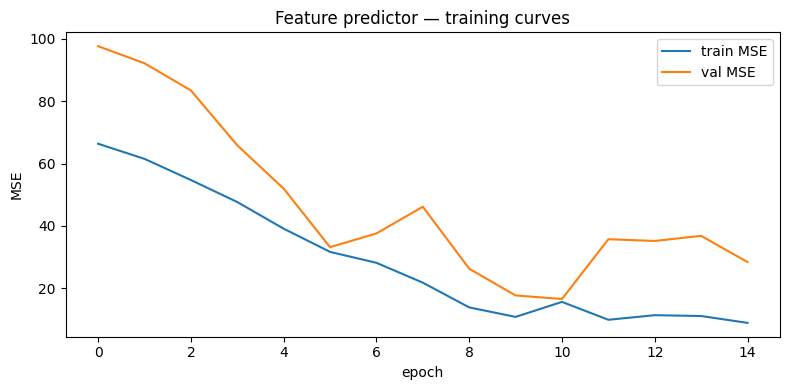

In [8]:
@torch.no_grad()
def evaluate_fp(model, loader):
    """Evaluate the feature predictor. Returns (y_true, y_pred) both shape (N, 2)."""
    model.eval()
    yts, yps = [], []
    for img, y, _ in loader:
        img = img.to(device)
        pred = model(img).cpu().numpy()
        yts.append(y.numpy()); yps.append(pred)
    return np.concatenate(yts), np.concatenate(yps)


def train_feature_predictor(model, train_loader, val_loader,
                            lr=1e-4, weight_decay=1e-4, epochs=20, patience=4):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    train_losses, val_losses = [], []
    best_val = float("inf"); best_state = None; no_improve = 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running, n = 0.0, 0
        for img, y, _ in train_loader:
            img = img.to(device, non_blocking=True)
            y   = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                pred = model(img)
                loss = criterion(pred, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()

            running += loss.item() * y.size(0); n += y.size(0)

        train_losses.append(running / n)

        # Val loss (MSE on raw features)
        yt_val, yp_val = evaluate_fp(model, val_loader)
        val_mse = float(((yt_val - yp_val) ** 2).mean())
        val_losses.append(val_mse)

        print(f"  epoch {epoch:02d}/{epochs} | train_mse={train_losses[-1]:.4f} | val_mse={val_mse:.4f}")

        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  early stopping at epoch {epoch}")
                break

    print(f"  done in {time.time() - t0:.0f}s | best val MSE = {best_val:.4f}")
    if best_state:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses

torch.manual_seed(2025)
feature_predictor = FeaturePredictor(dropout=0.3)
print("Training feature predictor (ResNet18 → NDVI + Height)...")
feature_predictor, fp_train_loss, fp_val_loss = train_feature_predictor(
    feature_predictor, fp_train_loader, fp_val_loader,
    lr=1e-4, weight_decay=1e-4, epochs=20, patience=4,
)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fp_train_loss, label="train MSE"); ax.plot(fp_val_loss, label="val MSE")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.legend()
ax.set_title("Feature predictor — training curves")
plt.tight_layout(); plt.show()


Note: the above code block was generated using system prompting, where I gave our other training loops used in our project to the Generative AI model as context and asked it to produce a training loop for this particular problem.

## 6. Evaluate the feature predictor

Pre_GSHH_NDVI       R²=-6.8455  MAE=0.2751  corr=0.2864
Height_Ave_cm       R²=0.7644  MAE=3.7282  corr=0.8990


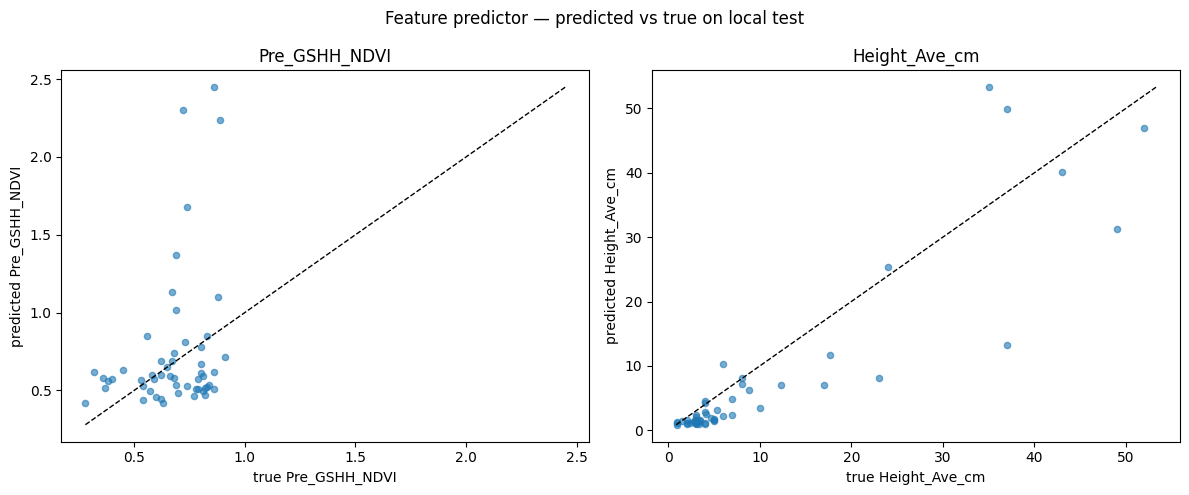

In [9]:
yt_fp, yp_fp = evaluate_fp(feature_predictor, fp_test_loader)

for i, feat_name in enumerate(TABULAR_FEATURES):
    true = yt_fp[:, i]; pred = yp_fp[:, i]
    ss_res = ((true - pred) ** 2).sum()
    ss_tot = ((true - true.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    mae = np.abs(true - pred).mean()
    corr = np.corrcoef(true, pred)[0, 1]
    print(f"{feat_name:18s}  R²={r2:.4f}  MAE={mae:.4f}  corr={corr:.4f}")

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, i, name in zip(axes, range(2), TABULAR_FEATURES):
    ax.scatter(yt_fp[:, i], yp_fp[:, i], s=20, alpha=0.6)
    lo = min(yt_fp[:, i].min(), yp_fp[:, i].min())
    hi = max(yt_fp[:, i].max(), yp_fp[:, i].max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_xlabel(f"true {name}"); ax.set_ylabel(f"predicted {name}")
    ax.set_title(name)
plt.suptitle("Feature predictor — predicted vs true on local test")
plt.tight_layout(); plt.show()


Note: AI is used for syntax needed for generating plots.

---
# Stage 2: LightGBM with predicted features

We train LightGBM on the true tabular features, then use the predicted features to evaluate model performance.


## 7. Feature engineering (reused from tabular notebook prior to Species being removed as a feature)

In [10]:
def engineer_features(df, fit_encoder=None, fit_scaler=None, fit_medians=None):
    feat = pd.DataFrame(index=df.index)

    if fit_medians is None:
        medians = {
            "Pre_GSHH_NDVI": float(df["Pre_GSHH_NDVI"].median()),
            "Height_Ave_cm": float(df["Height_Ave_cm"].median()),
        }
    else:
        medians = fit_medians

    feat["Pre_GSHH_NDVI"] = df["Pre_GSHH_NDVI"].fillna(medians["Pre_GSHH_NDVI"])
    feat["Height_Ave_cm"] = df["Height_Ave_cm"].fillna(medians["Height_Ave_cm"])

    dates = pd.to_datetime(df["Sampling_Date"], format="mixed", errors="coerce")
    if fit_medians is None:
        medians["month"] = float(dates.dt.month.median())
        medians["day_of_year"] = float(dates.dt.dayofyear.median())
        medians["year"] = float(dates.dt.year.median())

    feat["month"]       = dates.dt.month.fillna(medians["month"]).astype(float)
    feat["day_of_year"] = dates.dt.dayofyear.fillna(medians["day_of_year"]).astype(float)
    feat["year"]        = dates.dt.year.fillna(medians["year"]).astype(float)

    feat["month_sin"] = np.sin(2 * np.pi * feat["month"] / 12)
    feat["month_cos"] = np.cos(2 * np.pi * feat["month"] / 12)

    cat_cols = ["State", "Species"]
    cat_data = df[cat_cols].fillna("Unknown")

    if fit_encoder is None:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        cat_encoded = encoder.fit_transform(cat_data)
    else:
        encoder = fit_encoder
        cat_encoded = encoder.transform(cat_data)

    num_feats = feat.values.astype(np.float64)
    X = np.hstack([num_feats, cat_encoded])
    n_num = num_feats.shape[1]

    if fit_scaler is None:
        scaler = StandardScaler()
        X[:, :n_num] = scaler.fit_transform(X[:, :n_num])
    else:
        scaler = fit_scaler
        X[:, :n_num] = scaler.transform(X[:, :n_num])

    feature_names = list(feat.columns) + list(encoder.get_feature_names_out(cat_cols))
    return X, encoder, scaler, medians, feature_names


## 8. Train LightGBM on TRUE features (same as tabular notebook before Species was removed as a feature)

In [11]:
# Engineer features using true values
X_train_true, encoder, scaler, eng_medians, feature_names = engineer_features(train_df)
X_val_true, _, _, _, _ = engineer_features(val_df, encoder, scaler, eng_medians)

X_trainval_true = np.vstack([X_train_true, X_val_true])
y_trainval = np.vstack([y_train, y_val])

print(f"X_trainval: {X_trainval_true.shape}, features: {len(feature_names)}")

# HP search (abbreviated — use the best config from the tabular notebook)
best_cfg = {"learning_rate": 0.05, "num_leaves": 31, "n_estimators": 200}

y_log_tv = np.log1p(np.clip(y_trainval, 0, None))
lgbm_models = []
for k in range(5):
    m = lgb.LGBMRegressor(
        **best_cfg, random_state=2025, verbosity=-1,
        min_child_samples=5, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1,
    )
    m.fit(X_trainval_true, y_log_tv[:, k])
    lgbm_models.append(m)
print(f"Trained {len(lgbm_models)} LightGBM models")

# Evaluate with TRUE features (upper bound — same as tabular notebook)
X_test_true, _, _, _, _ = engineer_features(test_df, encoder, scaler, eng_medians)
lgbm_true_pred = np.clip(np.expm1(
    np.column_stack([m.predict(X_test_true) for m in lgbm_models])
), 0, None)
score_true = weighted_r2(y_test, lgbm_true_pred)
print(f"\nLightGBM with TRUE features — test weighted R²: {score_true:.4f} (upper bound)")


X_trainval: (304, 25), features: 25
Trained 5 LightGBM models

LightGBM with TRUE features — test weighted R²: 0.8726 (upper bound)


## 9. Run the full pipeline on local test set

Now we run the full pipeline: ResNet predicts the NVDI + Height from the images, then we use those along with the median tabular values for day of year, species, etc to generate predictions using the GBM trained on the true tabular data. Then, we do the same using the predicted NVDI + Height from the ResNet model with the true tabular values for day of year, species, etc.


In [12]:
# Step 1: Predict NDVI + Height from test images
yt_fp_test, yp_fp_test = evaluate_fp(feature_predictor, fp_test_loader)

# Step 2: Build a test dataframe with PREDICTED features replacing the true ones
test_df_predicted = test_df.copy()
test_df_predicted["Pre_GSHH_NDVI"] = yp_fp_test[:, 0]
test_df_predicted["Height_Ave_cm"] = yp_fp_test[:, 1]

# For State, Species, Sampling_Date — we assume they're NOT available at Kaggle
# test time. Replace with Unknown / median to simulate that.
test_df_no_meta = test_df_predicted.copy()
test_df_no_meta["State"] = "Unknown"
test_df_no_meta["Species"] = "Unknown"
test_df_no_meta["Sampling_Date"] = pd.NaT  # will get median-imputed

# Step 3: Engineer features from predicted values
X_test_predicted, _, _, _, _ = engineer_features(test_df_no_meta, encoder, scaler, eng_medians)

# Step 4: LightGBM predicts biomass
lgbm_pred_predicted = np.clip(np.expm1(
    np.column_stack([m.predict(X_test_predicted) for m in lgbm_models])
), 0, None)

score_predicted = weighted_r2(y_test, lgbm_pred_predicted)
print(f"Full pipeline (predicted features, no metadata) — test weighted R²: {score_predicted:.4f}")


Full pipeline (predicted features, no metadata) — test weighted R²: 0.3051


In [13]:
# Also test: predicted NDVI/Height but WITH true State/Species/Date
# (to isolate the effect of feature prediction vs missing metadata)
test_df_pred_with_meta = test_df.copy()
test_df_pred_with_meta["Pre_GSHH_NDVI"] = yp_fp_test[:, 0]
test_df_pred_with_meta["Height_Ave_cm"] = yp_fp_test[:, 1]

X_test_pred_meta, _, _, _, _ = engineer_features(test_df_pred_with_meta, encoder, scaler, eng_medians)
lgbm_pred_meta = np.clip(np.expm1(
    np.column_stack([m.predict(X_test_pred_meta) for m in lgbm_models])
), 0, None)
score_pred_meta = weighted_r2(y_test, lgbm_pred_meta)
print(f"Predicted NDVI/Height + true metadata — test weighted R²: {score_pred_meta:.4f}")


Predicted NDVI/Height + true metadata — test weighted R²: 0.5131


Note: AI was used to convert our Tabular pipeline for evaluation into one suited for the ensemble model.

## 10. Full comparison

                                        model  test_wR2
       LightGBM (true features — upper bound)  0.872625
 LightGBM (predicted NDVI/Height + true meta)  0.513132
LightGBM (predicted NDVI/Height, no metadata)  0.305106
                                Mean baseline  0.212215


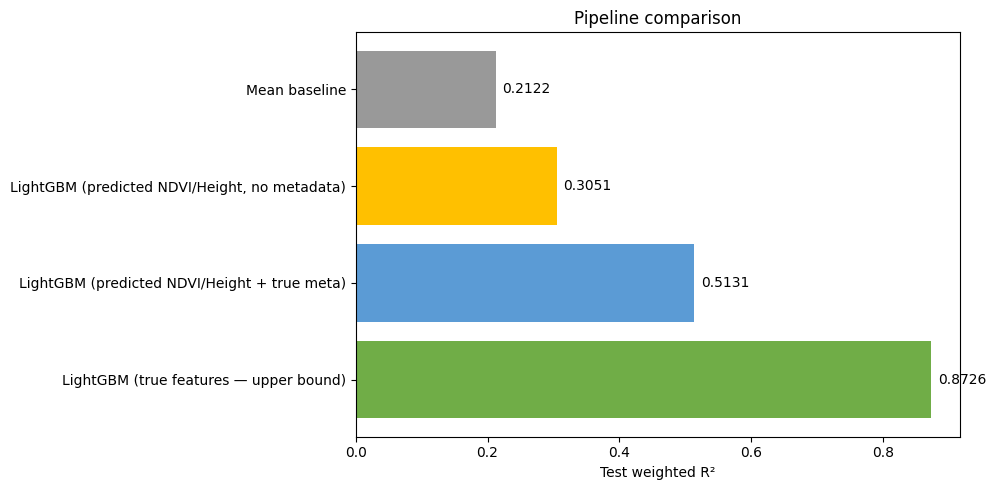

In [14]:
# Mean baseline
baseline_pred = np.tile(train_df[TARGETS].mean().values, (len(test_df), 1))
score_baseline = weighted_r2(y_test, baseline_pred)

summary = pd.DataFrame([
    {"model": "Mean baseline",                                 "test_wR2": score_baseline},
    {"model": "LightGBM (true features — upper bound)",        "test_wR2": score_true},
    {"model": "LightGBM (predicted NDVI/Height + true meta)",  "test_wR2": score_pred_meta},
    {"model": "LightGBM (predicted NDVI/Height, no metadata)", "test_wR2": score_predicted},
]).sort_values("test_wR2", ascending=False)
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#70AD47", "#5B9BD5", "#FFC000", "#999999"]
bars = ax.barh(summary["model"], summary["test_wR2"], color=colors)
ax.set_xlabel("Test weighted R²"); ax.set_title("Pipeline comparison")
for bar, v in zip(bars, summary["test_wR2"]):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f"{v:.4f}", va="center")
plt.tight_layout(); plt.show()


In [15]:
# Per-target breakdown for the full pipeline
print("\n=== Full pipeline (predicted features, no metadata) ===")
print(per_target_metrics(y_test, lgbm_pred_predicted).to_string(index=False))



=== Full pipeline (predicted features, no metadata) ===
             target  weight        R2       MAE      RMSE
        Dry_Green_g     0.1  0.247051 15.099007 21.172725
         Dry_Dead_g     0.1 -0.172316  8.149584 11.456104
       Dry_Clover_g     0.1 -0.094940  5.895437 10.810060
              GDM_g     0.2  0.221549 16.546136 22.317527
        Dry_Total_g     0.5  0.064528 21.955451 27.389601
OVERALL_weighted_R2     NaN  0.305106       NaN       NaN


Syntax for tables, plots assisted by Generative AI.

## 11. Error analysis on the full pipeline

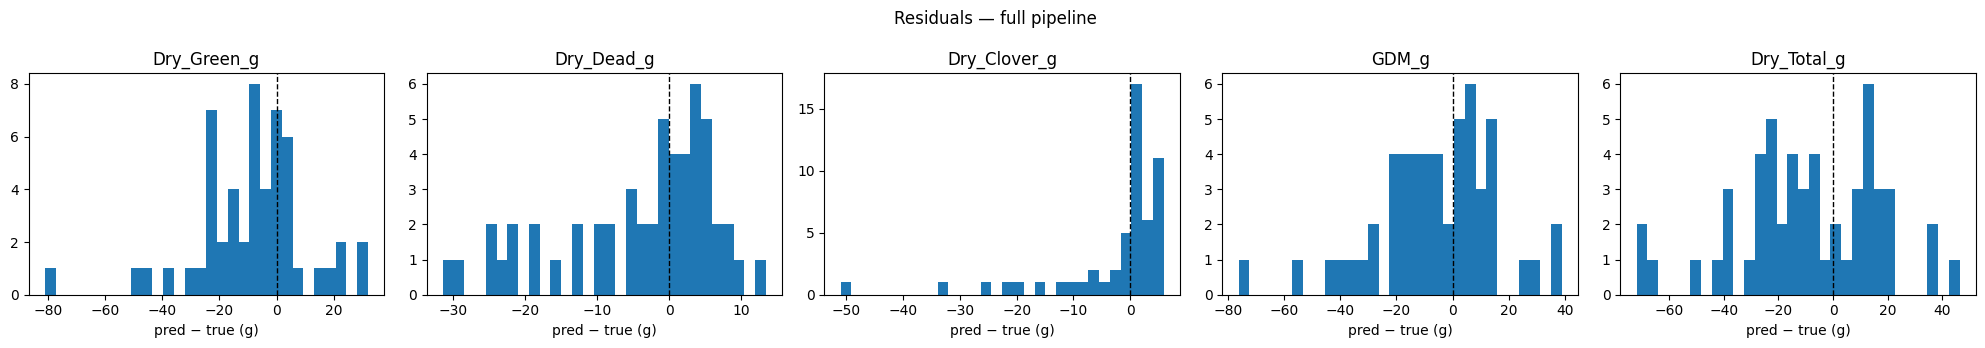

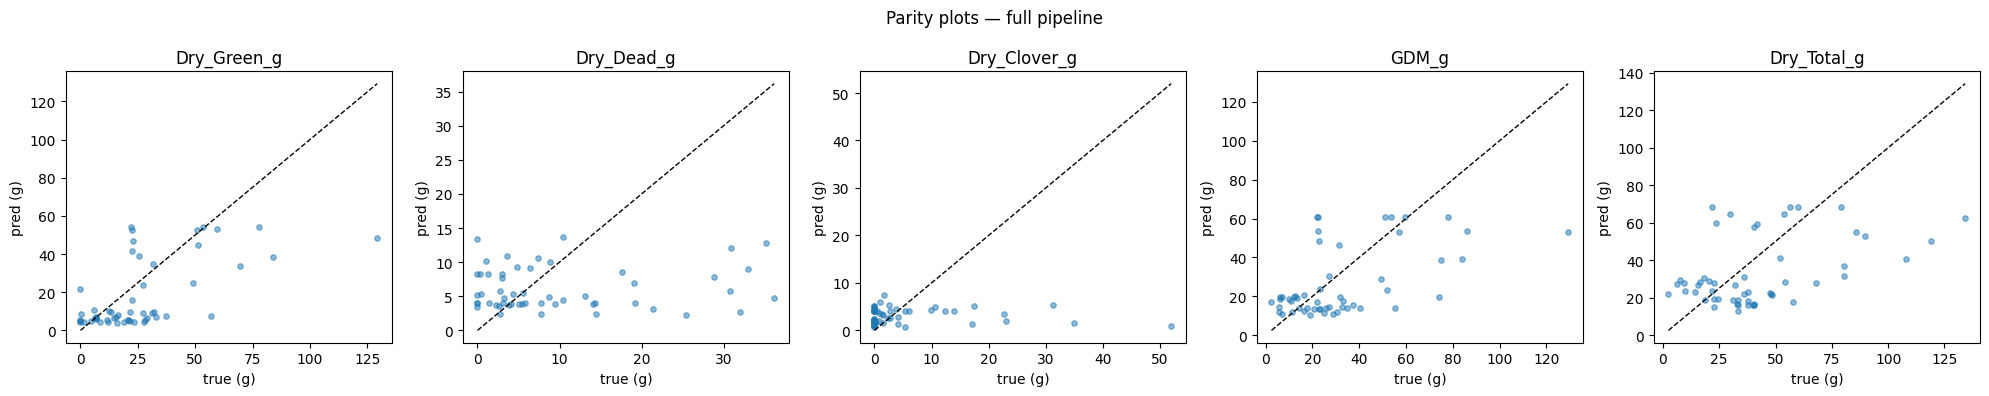

In [16]:
# Residuals
resid = lgbm_pred_predicted - y_test
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, t, k in zip(axes, TARGETS, range(5)):
    ax.hist(resid[:, k], bins=30)
    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.set_title(t); ax.set_xlabel("pred − true (g)")
plt.suptitle("Residuals — full pipeline")
plt.tight_layout(); plt.show()

# Parity plots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, t, k in zip(axes, TARGETS, range(5)):
    ax.scatter(y_test[:, k], lgbm_pred_predicted[:, k], s=15, alpha=0.5)
    lo = min(y_test[:, k].min(), lgbm_pred_predicted[:, k].min())
    hi = max(y_test[:, k].max(), lgbm_pred_predicted[:, k].max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_title(t); ax.set_xlabel("true (g)"); ax.set_ylabel("pred (g)")
plt.suptitle("Parity plots — full pipeline")
plt.tight_layout(); plt.show()


Again, syntax for plots aided by AI.

As we can observe, this pipeline of prediction of NVDI + Height along with the true tabular features on the train set results in a much worse performance than the LightGBM, indicating that this method is likely not the path forward. Further evidencing this is the fact that when we used the predicted features along with information we had at inference time for the other tabular features (re: just the median of the dataset for day of year, etc), the model performed only slightly better than the true baseline model with an R-squared of ~0.3.

On top of this, even giving the model more information than other models we have trained thus far (re: ViT), such as the true tabular values for day of year, species, etc, we still observe it performing worse than those that only use information available at inference time (mainly, the image itself), with an R-squared of ~0.5 on the local test set, which is lower than the ViT output. This is also clear in the residuals of this model, as its predictions in particular for Dry_Clover_g and Dry_Dead_g appear uncorrelated from the true values. Thus, while this was an interesting experiment to run, it appears that limiting what the vision models can learn to just the features that we deem important is likely not the path forward.